## FIDELITYBK STOCK PRICE PREDICTION

In [2]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

fidelitybk=pd.read_csv('../stock_data/fidelitybk.csv') ## so it can be small letter. This is cool.
fidelitybk=fidelitybk.drop(columns=['high_price','low_price'])
fidelitybk.rename(columns={'trade_date':'date'},inplace=True)
fidelitybk['date']=pd.to_datetime(fidelitybk['date'])
fidelitybk['month']=fidelitybk['date'].dt.month
fidelitybk['quarter']=fidelitybk['date'].dt.quarter
fidelitybk['year']=fidelitybk['date'].dt.year

fidelitybk

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42807,FIDELITYBK,2017-01-03,0.83,0.83,1846183,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43367,FIDELITYBK,2017-01-04,0.85,0.85,2371712,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43477,FIDELITYBK,2017-01-05,0.83,0.83,25056912,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43587,FIDELITYBK,2017-01-06,0.83,0.83,9621483,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43677,FIDELITYBK,2017-01-09,0.90,0.90,33853569,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298060,FIDELITYBK,2026-07-13,19.50,19.50,16601214,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298498,FIDELITYBK,2026-07-14,19.90,19.90,10592211,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298936,FIDELITYBK,2026-07-15,20.95,20.95,27255775,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299374,FIDELITYBK,2026-07-16,21.25,21.25,23807815,2026-07-16T15:10:03.113936+00:00,7,3,2026


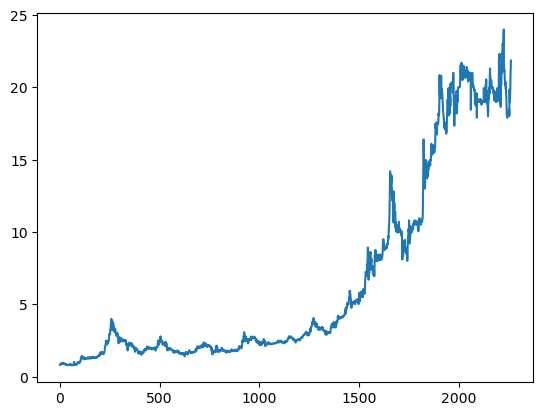

In [3]:
import matplotlib.pyplot as plt

plt.plot(fidelitybk['close_price'])
plt.show()

In [4]:
fidelitybk_end_month_df = (
    fidelitybk
    .sort_values("date")
    .groupby(fidelitybk["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

fidelitybk_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45377,FIDELITYBK,2017-01-31,0.92,0.92,12221990,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47198,FIDELITYBK,2017-02-28,0.81,0.81,3226919,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49314,FIDELITYBK,2017-03-31,0.79,0.79,41838473,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51142,FIDELITYBK,2017-04-28,0.82,0.82,42278426,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53064,FIDELITYBK,2017-05-31,1.04,1.04,38775141,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35298,FIDELITYBK,2026-03-31,19.00,19.00,12881923,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281124,FIDELITYBK,2026-04-30,20.00,20.00,12466439,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284190,FIDELITYBK,2026-05-29,21.10,21.10,4552232,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294118,FIDELITYBK,2026-06-30,18.35,18.35,12892216,2026-06-30T15:10:03.08168+00:00,6,2,2026


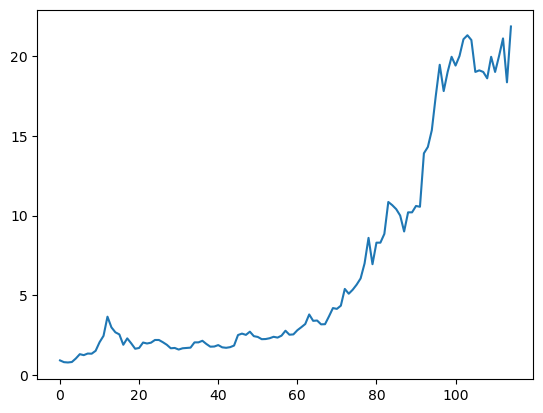

In [5]:
plt.plot(fidelitybk_end_month_df['close_price'])
plt.show()

In [6]:
fidelitybk_end_month_df['returns']=fidelitybk_end_month_df['close_price'].pct_change()*100
fidelitybk_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45377,FIDELITYBK,2017-01-31,0.92,0.92,12221990,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47198,FIDELITYBK,2017-02-28,0.81,0.81,3226919,2026-04-08T02:44:45.006295+00:00,2,1,2017,-11.956522
2,49314,FIDELITYBK,2017-03-31,0.79,0.79,41838473,2026-04-08T02:45:42.281198+00:00,3,1,2017,-2.469136
3,51142,FIDELITYBK,2017-04-28,0.82,0.82,42278426,2026-04-08T02:51:55.619599+00:00,4,2,2017,3.797468
4,53064,FIDELITYBK,2017-05-31,1.04,1.04,38775141,2026-04-08T02:52:57.421655+00:00,5,2,2017,26.829268
...,...,...,...,...,...,...,...,...,...,...,...
110,35298,FIDELITYBK,2026-03-31,19.00,19.00,12881923,2026-03-31T15:00:02.085058+00:00,3,1,2026,-4.761905
111,281124,FIDELITYBK,2026-04-30,20.00,20.00,12466439,2026-04-30T15:00:02.170664+00:00,4,2,2026,5.263158
112,284190,FIDELITYBK,2026-05-29,21.10,21.10,4552232,2026-05-29T15:00:02.455558+00:00,5,2,2026,5.500000
113,294118,FIDELITYBK,2026-06-30,18.35,18.35,12892216,2026-06-30T15:10:03.08168+00:00,6,2,2026,-13.033175


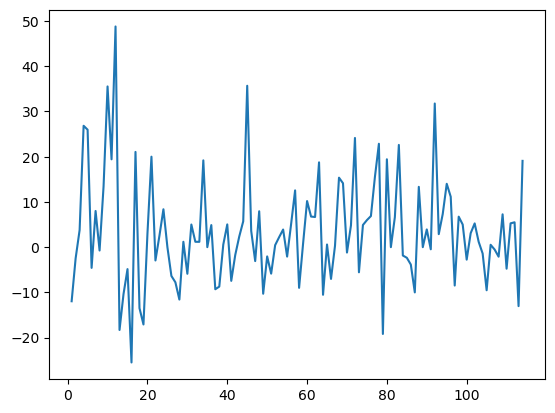

In [7]:
plt.plot(fidelitybk_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(fidelitybk_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.29354090283892), np.float64(3.519022793013997e-18), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(754.938642216559))
stationary


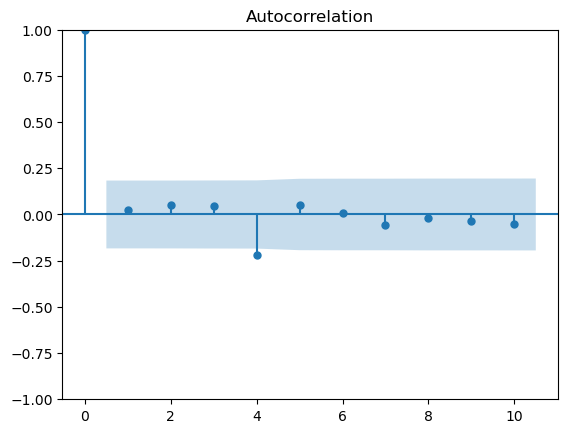

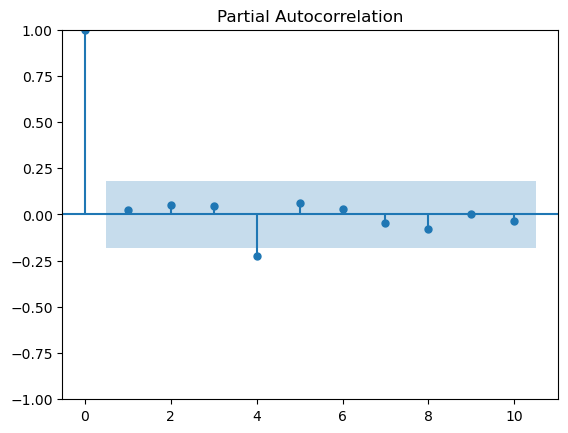

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(fidelitybk_end_month_df['returns'].dropna(), lags=10)
plot_pacf(fidelitybk_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=fidelitybk_end_month_df['close_price'][:-10]
test=fidelitybk_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -334.2523449911858]
[0, 0, 0, 0, 0, 1, -61.30263592041206]
[0, 0, 0, 0, 0, 2, -15.418974874568825]
[0, 0, 0, 0, 1, 0, -3.3528694857341828]
[0, 0, 0, 0, 1, 1, -17.21574341558448]
[0, 0, 0, 0, 1, 2, -26.07165687093849]
[0, 0, 0, 0, 2, 0, -54.4305860844406]
[0, 0, 0, 0, 2, 1, -60.13113644690054]
[0, 0, 0, 0, 2, 2, -62.802563435905164]
[0, 0, 0, 1, 0, 0, -5.779619898789476]
[0, 0, 0, 1, 0, 1, -11.105914197033405]
[0, 0, 0, 1, 0, 2, -18.744124248072755]
[0, 0, 0, 1, 1, 0, -40.73175322239808]
[0, 0, 0, 1, 1, 1, -44.00480526399314]
[0, 0, 0, 1, 1, 2, -47.373396056101534]
[0, 0, 0, 1, 2, 0, -65.94092348443539]
[0, 0, 0, 1, 2, 1, -74.00391239488431]
[0, 0, 0, 1, 2, 2, -68.30569432481869]
[0, 0, 0, 2, 0, 0, -25.010695669442235]
[0, 0, 0, 2, 0, 1, -28.533903692932505]
[0, 0, 0, 2, 0, 2, -32.23989028112577]
[0, 0, 0, 2, 1, 0, -47.00946966336284]
[0, 0, 0, 2, 1, 1, -38.66154077795707]
[0, 0, 0, 2, 1, 2, -48.998959430174494]
[0, 0, 0, 2, 2, 0, -68.48754690694193]
[0, 0, 0, 2, 2, 1

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-594.914819
177,0,2,0,1,2,0,-501.554798
186,0,2,0,2,2,0,-356.007410
0,0,0,0,0,0,0,-334.252345
169,0,2,0,0,2,1,-326.917348
...,...,...,...,...,...,...,...
416,1,2,0,1,0,2,-1.342318
424,1,2,0,2,0,1,-1.341612
540,2,0,2,0,0,0,-1.261806
406,1,2,0,0,0,1,-1.213160


Its not capturing the variations properly. Lets try the returns

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=fidelitybk_end_month_df['returns'].dropna()[:-10]
test=fidelitybk_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.007780576981735177]
[0, 0, 0, 0, 0, 1, -0.08722355126599002]
[0, 0, 0, 0, 0, 2, -0.08526074406116235]
[0, 0, 0, 0, 1, 0, -0.964138711834728]
[0, 0, 0, 0, 1, 1, -1.0361170219278102]
[0, 0, 0, 0, 1, 2, -1.004640005225069]
[0, 0, 0, 0, 2, 0, -3.381478935723271]
[0, 0, 0, 0, 2, 1, -0.6515836102966794]
[0, 0, 0, 0, 2, 2, -0.14629931166228927]
[0, 0, 0, 1, 0, 0, -0.1145660077515418]
[0, 0, 0, 1, 0, 1, -0.657034512331758]
[0, 0, 0, 1, 0, 2, -0.740679146156086]
[0, 0, 0, 1, 1, 0, -0.6431886483863967]
[0, 0, 0, 1, 1, 1, -1.0005887609639443]
[0, 0, 0, 1, 1, 2, -0.9881051598419004]
[0, 0, 0, 1, 2, 0, -1.5210583913719287]
[0, 0, 0, 1, 2, 1, -0.25191352887397067]
[0, 0, 0, 1, 2, 2, -0.07622529019167334]
[0, 0, 0, 2, 0, 0, -0.11496764019433581]
[0, 0, 0, 2, 0, 1, -0.7653955513545603]
[0, 0, 0, 2, 0, 2, -0.7167744092014905]
[0, 0, 0, 2, 1, 0, -0.695971205263513]
[0, 0, 0, 2, 1, 1, -1.1960824514325257]
[0, 0, 0, 2, 1, 2, -0.9826609095211618]
[0, 0, 0, 2, 2, 0, -1.613466248462184]

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
702,2,2,2,0,0,0,-96763.116507
186,0,2,0,2,2,0,-1666.708297
177,0,2,0,1,2,0,-1573.668615
178,0,2,0,1,2,1,-1289.951147
170,0,2,0,0,2,2,-1158.225277
...,...,...,...,...,...,...,...
243,1,0,0,0,0,0,-0.003474
432,1,2,1,0,0,0,0.000904
296,1,0,1,2,2,2,0.007119
287,1,0,1,1,2,2,0.051927


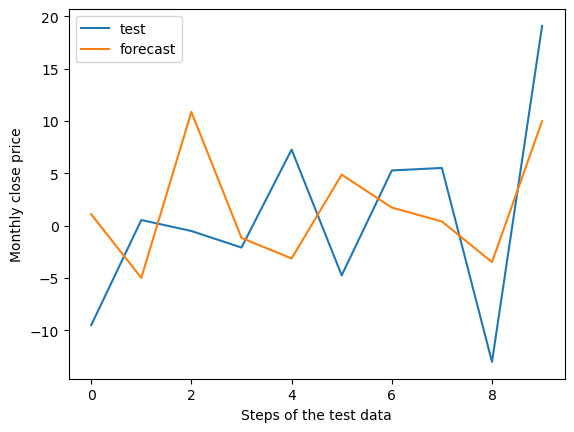

r2_score:  0.09231782451801174
rmse:  8.287977012938155
description:  count    114.000000
mean       3.482308
std       12.034369
min      -25.490196
25%       -3.042986
50%        1.701433
75%        7.321509
max       48.780488
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=fidelitybk_end_month_df['returns'].dropna()[:-10]
y_test=fidelitybk_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,1), 
seasonal_order=(0,2,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', fidelitybk_end_month_df.returns.dropna().describe())

Very ureliable forecast. We will return.
